# IMPORT

In [75]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Remonte de deux niveaux (si ton notebook est dans /notebooks/exploration.ipynb)
# pour atteindre la racine du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from config.config import *

In [76]:
# Chemins vers les fichiers CSV
cancer_csv = BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / "summary_cancer_images.csv"
normal_csv = BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / "summary_normal_images.csv"

# Lecture et concaténation avec ajout du type
df_cancer = pd.read_csv(cancer_csv)
df_cancer['path'] = df_cancer['name'].apply(lambda x: str(cancer_csv.parent / "cancer" / x))
df_cancer['type'] = 'cancer'

df_normal = pd.read_csv(normal_csv)
df_normal['path'] = df_normal['name'].apply(lambda x: str(normal_csv.parent / "normal" / x))
df_normal['type'] = 'normal'

df_meta = pd.concat([df_cancer, df_normal], ignore_index=True)

# On garde les colonnes utiles pour la fusion
df_meta = df_meta[['name','path', 'orientation', 'type']]

In [77]:
df_normal.head()

,Unnamed: 0,name,format,width,height,mode,file_size,orientation,path,type
0,0,0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg,JPEG,512,512,RGB,23557,top,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,normal
1,1,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,JPEG,512,512,RGB,26027,top,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,normal
2,2,11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg,JPEG,512,512,RGB,28994,top,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,normal
3,3,14703976-0467-4acb-ade4-8a375ebfd4f9.jpg,JPEG,512,512,RGB,27527,top,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,normal
4,4,1953e998-29b8-4d36-975f-007c4fcb84a3.jpg,JPEG,512,512,RGB,28816,top,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,normal


In [60]:
df = pd.read_parquet(BASE_DIR / "mri_dataset_brain_cancer_oc" / "features.parquet")

In [61]:
df.head()

,name,features
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,"[0.40974900126457214, 0.8732983469963074, 0.17..."
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541..."
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077..."
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174..."
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39..."


In [62]:
# Fusion (Left join pour garder toutes les images, même sans orientation)
df_merged = pd.merge(df, df_meta, on='name', how='left')

# Pour les images "sans_label", l'orientation et le type seront NaN, on peut les remplir
df_merged['orientation'] = df_merged['orientation'].fillna('unknown')
df_merged['type'] = df_merged['type'].fillna('unknown')

In [63]:
X  = np.asarray(df.features.tolist())
print(X.shape)
print(X[:5])

(1506, 2048)
[[0.409749   0.87329835 0.17418274 ... 0.43045837 1.09906232 0.93881273]
 [0.65022993 0.72121131 0.05412548 ... 0.48573419 0.67198437 0.70614064]
 [1.19296503 1.13145077 0.10771205 ... 0.43856546 0.29744983 1.48325908]
 [0.49469411 0.45606458 0.17403413 ... 0.56383592 0.95019448 1.11259449]
 [0.49190512 0.35454875 0.39020169 ... 0.42974672 1.46340895 1.06851077]]


In [64]:
std = StandardScaler()
X_std = std.fit_transform(X)

In [65]:
# réduit les dimensions de 2048 à 128. ici la réduction explique 88% des données
pca = PCA(n_components=128,random_state=42)
X_pca = pca.fit_transform(X_std)
print(pca.explained_variance_ratio_.sum())


0.887830763279462


In [66]:
# On réduit les composants à 2 dimensions pour visualiser ET clusteriser
import umap

# On utilise UMAP pour projeter en 2D en premier
umap_2d = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_2d.fit_transform(X_pca)

c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


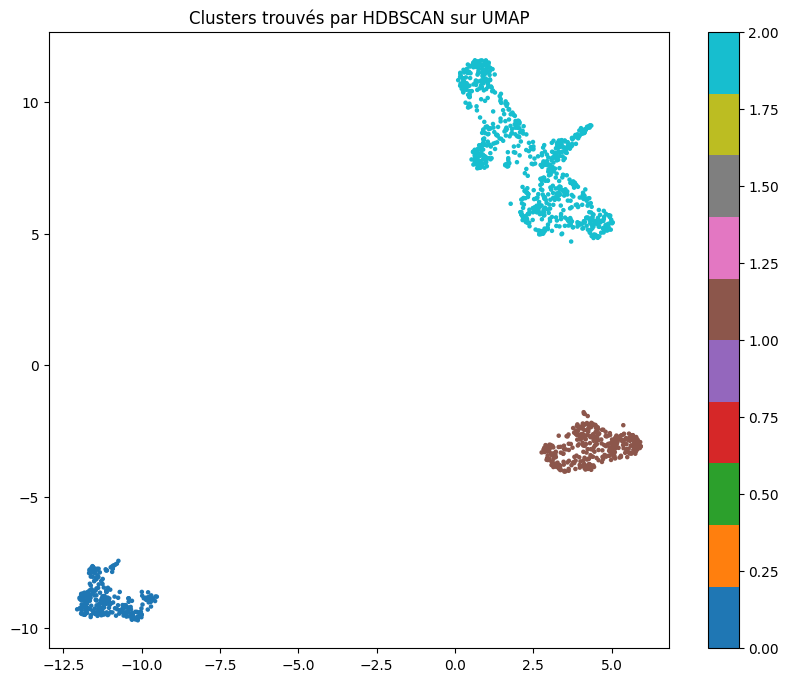

In [67]:
# Clustering sur les coordonnées UMAP (2D)
# Cela permet de capturer les groupes visuels que l'on observe
import hdbscan

# On peut ajuster min_cluster_size si besoin pour bien séparer les 3 groupes
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30, 
    min_samples=5,
    metric='euclidean'
)

labels = clusterer.fit_predict(X_umap)

# Visualisation simple des clusters trouvés
plt.figure(figsize=(10, 8))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab10', s=5)
plt.title("Clusters trouvés par HDBSCAN sur UMAP")
plt.colorbar()
plt.show()

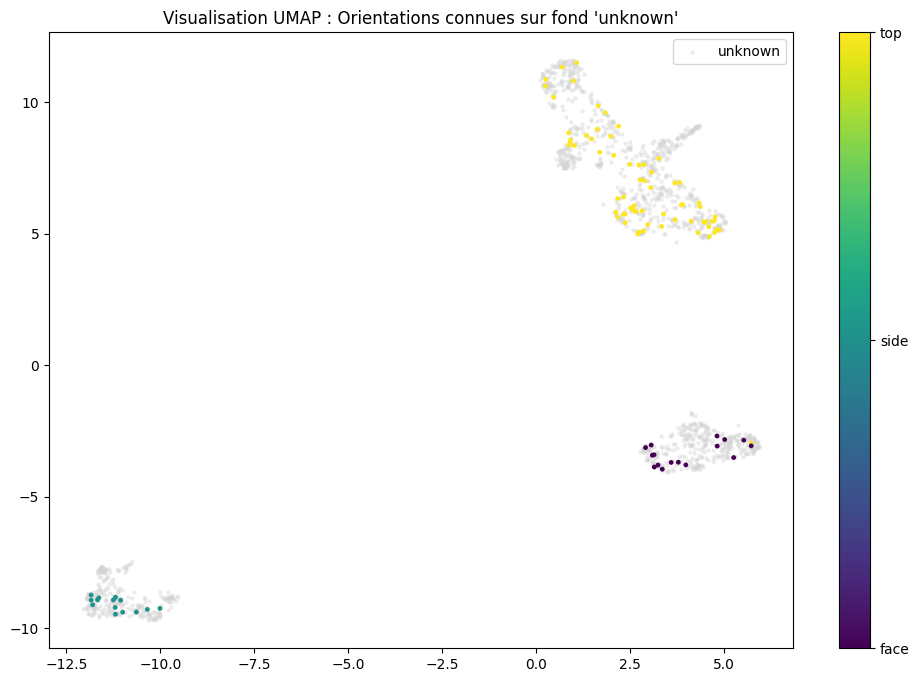

Répartition des orientations par cluster :
orientation  face  side  top  unknown
row_0                                
0               0    14    0      282
1              16     0    1      356
2               0     0   69      768


In [68]:
# On s'assure que l'orientation est catégorielle
df_merged['orientation'] = df_merged['orientation'].astype('category')

# Séparation des masques
is_unknown = df_merged['orientation'] == 'unknown'
is_known = ~is_unknown

# Extraction des catégories connues pour la légende (sans unknown)
known_categories = df_merged.loc[is_known, 'orientation'].cat.remove_unused_categories().cat.categories
colors_known = df_merged.loc[is_known, 'orientation'].cat.remove_unused_categories().cat.codes

plt.figure(figsize=(12, 8))

# 1. On trace les 'unknown' en premier (arrière-plan) en gris clair
plt.scatter(
    X_umap[is_unknown, 0], 
    X_umap[is_unknown, 1], 
    c='lightgray', 
    label='unknown', 
    s=5, 
    alpha=0.3
)

# 2. On trace les points connus par dessus
scatter = plt.scatter(
    X_umap[is_known, 0], 
    X_umap[is_known, 1], 
    c=colors_known, 
    cmap='viridis', 
    s=12,
    edgecolors='none'
)

# Barre de couleur pour les catégories connues
cbar = plt.colorbar(scatter, ticks=range(len(known_categories)))
cbar.set_ticklabels(known_categories)

plt.title("Visualisation UMAP : Orientations connues sur fond 'unknown'")
plt.legend(loc='upper right')
plt.show()

# Vérification statistique
print("Répartition des orientations par cluster :")
print(pd.crosstab(labels, df_merged['orientation']))

# Observation

On valide le fait que le modèle RESNET identifie clairement 3 grands groupes :
- les photos de face
- les photos de coté
- les photos de haut

**Nous pouvons donc dors et déjà annoter l'orientation des photos automatiquement**

In [69]:
# 1. Attacher les labels de clusters calculés par HDBSCAN au DataFrame
df_merged['cluster_label'] = labels

# 2. Identifier l'orientation dominante pour chaque cluster
# On ignore 'unknown' pour trouver la "vraie" orientation du groupe
cluster_dominant_orient = (
    df_merged[df_merged['orientation'] != 'unknown']
    .groupby('cluster_label')['orientation']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else 'unknown')
)

# 3. Créer la colonne 'weak_orientation'
# On initialise avec l'orientation connue
df_merged['weak_orientation'] = df_merged['orientation']

# 4. Mapper les 'unknown' vers l'orientation dominante de leur cluster
mask_unknown = df_merged['orientation'] == 'unknown'
df_merged.loc[mask_unknown, 'weak_orientation'] = df_merged.loc[mask_unknown, 'cluster_label'].map(cluster_dominant_orient)

# 5. Gestion des cas particuliers (ex: points de bruit -1 sans orientation dominante)
df_merged['weak_orientation'] = df_merged['weak_orientation'].fillna('unknown')

print("Statistiques de l'auto-labellisation :")
print(f"Nombre d'images initialement 'unknown' : {mask_unknown.sum()}")
print(f"Nombre d'images 'unknown' après mapping : {(df_merged['weak_orientation'] == 'unknown').sum()}")
print("\nRépartition finale de 'weak_orientation' :")
print(df_merged['weak_orientation'].value_counts())

# Aperçu du résultat
df_merged[['name', 'path', 'orientation', 'weak_orientation', 'cluster_label']].head(5)

Statistiques de l'auto-labellisation :
Nombre d'images initialement 'unknown' : 1406
Nombre d'images 'unknown' après mapping : 0

Répartition finale de 'weak_orientation' :
weak_orientation
top        838
face       372
side       296
unknown      0
Name: count, dtype: int64


,name,path,orientation,weak_orientation,cluster_label
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,side,side,0
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,top,2
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,top,2
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,top,2
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,top,2


In [70]:
# Vérification : les images déjà labellisées doivent garder leur orientation
mask_labeled = df_merged['orientation'] != 'unknown'
diff = (df_merged.loc[mask_labeled, 'orientation'] != df_merged.loc[mask_labeled, 'weak_orientation']).sum()
print(f"Nombre d'images labellisées dont l'orientation a changé : {diff}")

Nombre d'images labellisées dont l'orientation a changé : 0


In [71]:
weak_side_images = df_merged[df_merged['weak_orientation']=='side']
weak_side_images.shape

(296, 7)

Images side trouvées : 282


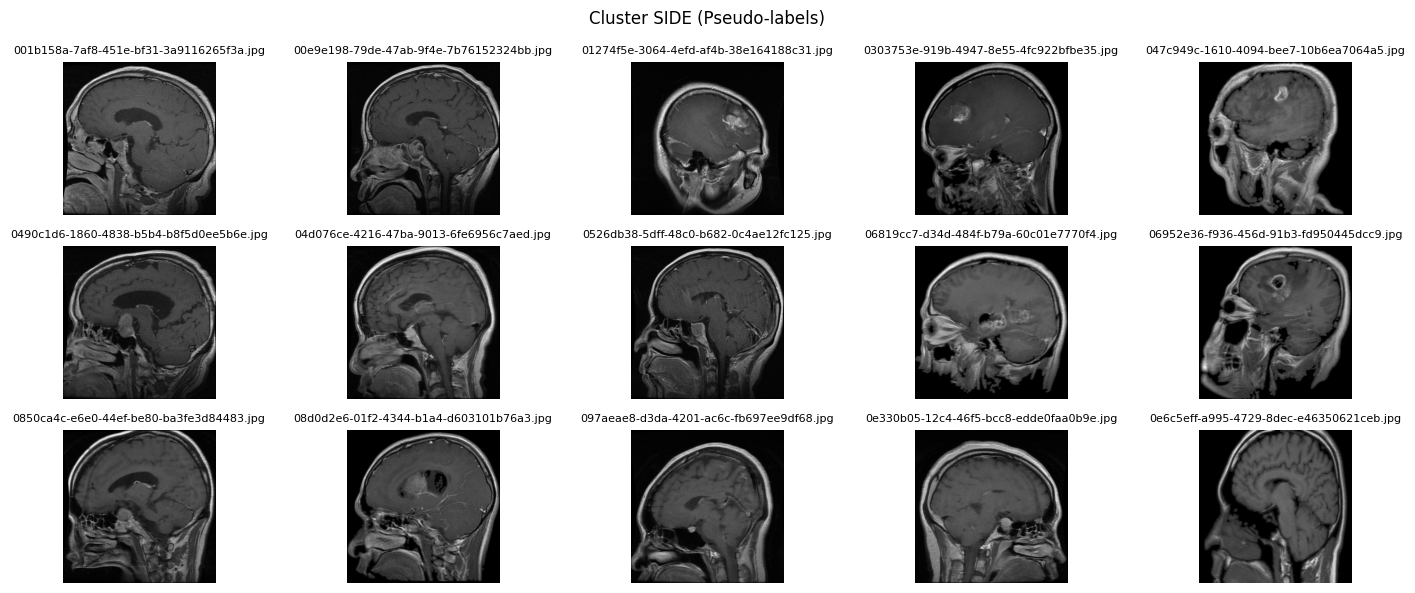

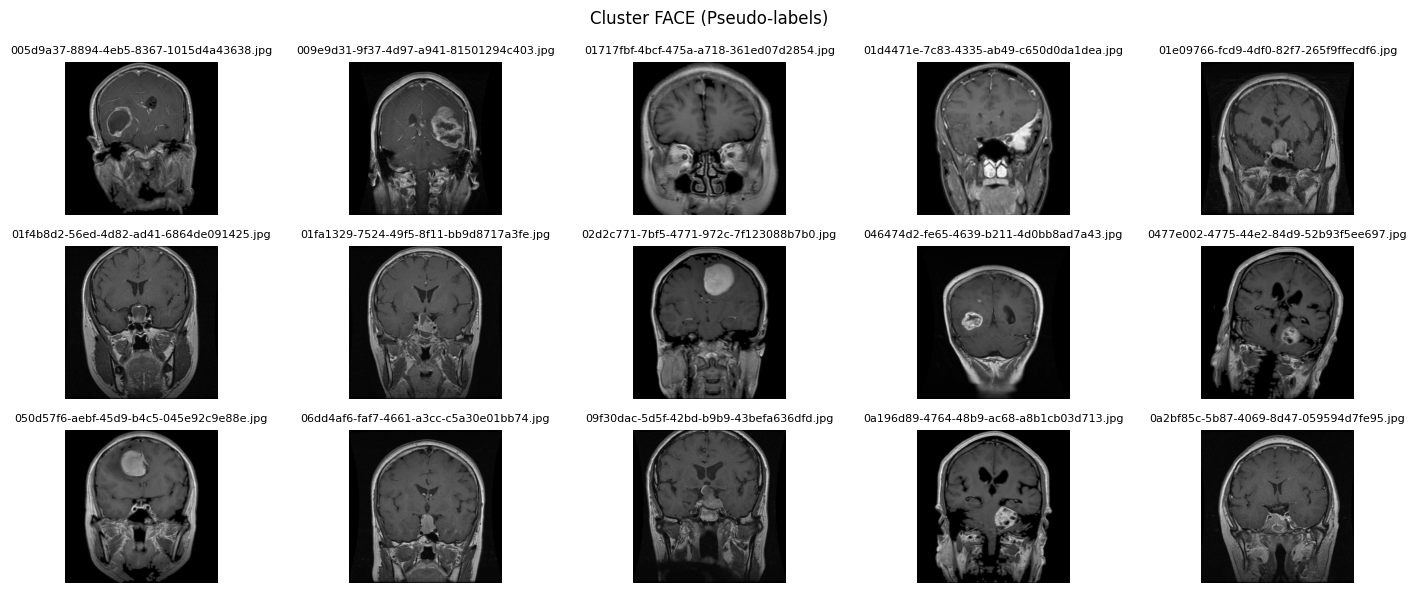

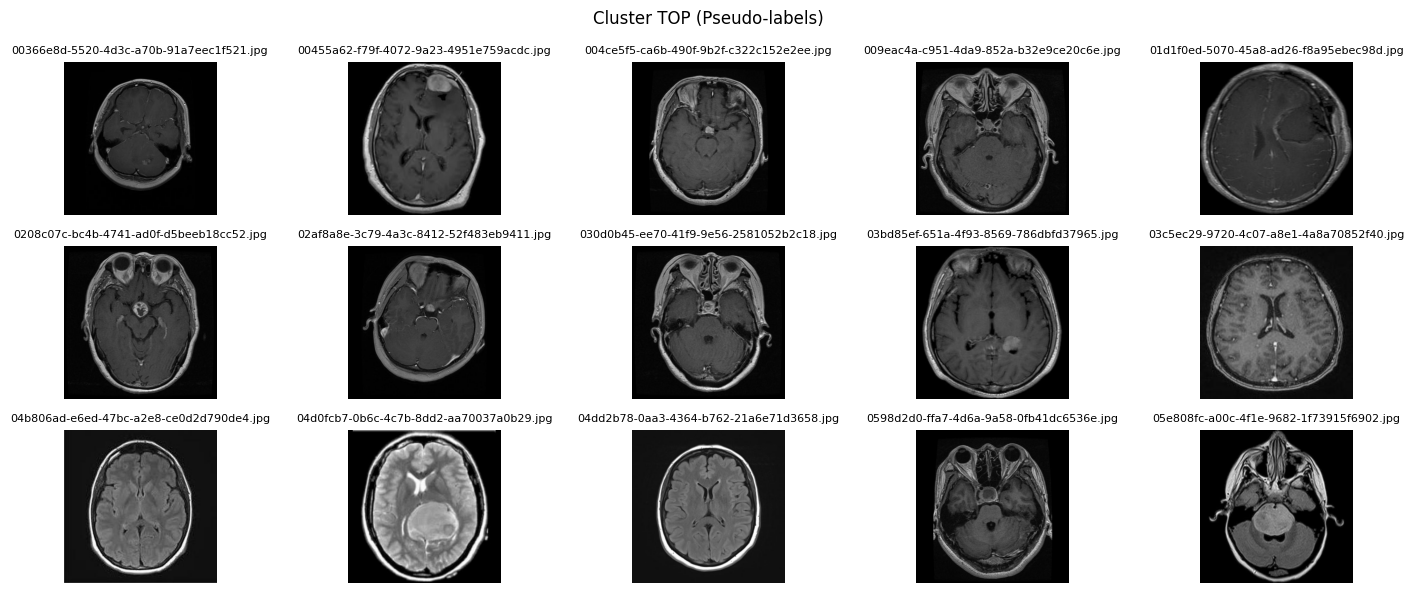

In [72]:
# Visualisation des images identifiées comme 'side' et qui étaient 'unknown'
# La condition (df_merged['orientation'] == 'unknown') est cruciale car les images déjà
# connues ne sont PAS dans le dossier "sans_label".

weak_side_images = df_merged[
    (df_merged['weak_orientation']=='side') & 
    (df_merged['orientation']=='unknown')   # Correction typo et filtrage sur inconnus
]

print(f"Images side trouvées : {len(weak_side_images)}")

if len(weak_side_images) > 0:
    n_display_side = min(len(weak_side_images), 15)
    fig, axes = plt.subplots(3, 5, figsize=(15, 6))
    axes = axes.flatten()
    images_sans_label_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "sans_label"

    for idx, img_name in enumerate(weak_side_images['name'][:n_display_side]):
        img_path = images_sans_label_dir / img_name
        # Vérification existence fichier pour éviter crash
        if img_path.exists():
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(img_name, fontsize=8)
        else:
            print(f"Fichier manquant : {img_path}")
        axes[idx].axis('off')
    plt.suptitle("Cluster SIDE (Pseudo-labels)")
    plt.tight_layout()
    plt.show()

# Visualisation des images identifiées comme 'face'
weak_face_images = df_merged[
    (df_merged['weak_orientation']=='face') & 
    (df_merged['orientation']=='unknown')
]

if len(weak_face_images) > 0:
    n_display_face = min(len(weak_face_images), 15)
    fig, axes = plt.subplots(3, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for idx, img_name in enumerate(weak_face_images['name'][:n_display_face]):
        img_path = images_sans_label_dir / img_name
        if img_path.exists():
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(img_name, fontsize=8)
        axes[idx].axis('off')
    plt.suptitle("Cluster FACE (Pseudo-labels)")
    plt.tight_layout()
    plt.show()

# Visualisation des images identifiées comme 'top'
weak_face_images = df_merged[
    (df_merged['weak_orientation']=='top') & 
    (df_merged['orientation']=='unknown')
]

if len(weak_face_images) > 0:
    n_display_face = min(len(weak_face_images), 15)
    fig, axes = plt.subplots(3, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for idx, img_name in enumerate(weak_face_images['name'][:n_display_face]):
        img_path = images_sans_label_dir / img_name
        if img_path.exists():
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(img_name, fontsize=8)
        axes[idx].axis('off')
    plt.suptitle("Cluster TOP (Pseudo-labels)")
    plt.tight_layout()
    plt.show()

In [73]:
df_merged.to_parquet(BASE_DIR / "mri_dataset_brain_cancer_oc" / "images_orientation.parquet")

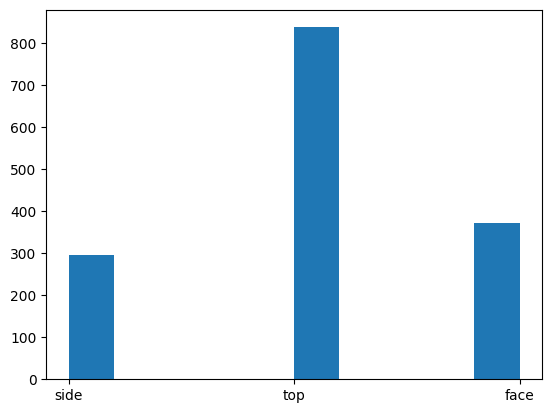

In [74]:
plt.hist(df_merged['weak_orientation'])

plt.show()